# Análisis ConnectaTel

Como **analista de datos**, tu objetivo es evaluar el **comportamiento de los clientes** de una empresa de telecomunicaciones en Latinoamérica, ConnectaTel. 

Trabajaremos con información registrada **hasta el año 2024**, lo cual permitirá analizar el comportamiento del negocio dentro de ese periodo.

Para ello trabajarás con tres datasets:  

- **plans.csv** → información de los planes actuales (precio, minutos incluidos, GB incluidos, costo por extra)  
- **users.csv** → información de los clientes (edad, ciudad, fecha de registro, plan, churn)  
- **usage.csv** → detalle del **uso real** de los servicios (llamadas y mensajes)  

Deberás **explorar**, **limpiar** y **analizar** estos datos para construir un **perfil estadístico** de los clientes, detectar **comportamientos atípicos** y crear **segmentos de clientes**.  

Este análisis te permitirá **identificar patrones de consumo**, **diseñar estrategias de retención** y **sugerir mejoras en los planes** ofrecidos por la empresa.

> 💡 Antes de empezar, recuerda pensar de forma **programática**: ¿qué pasos necesitas? ¿En qué orden? ¿Qué quieres medir y por qué?


--- 
## 🧩 Paso 1: Cargar y explorar

Antes de limpiar o combinar los datos, es necesario **familiarizarte con la estructura de los tres datasets**.  
En esta etapa, validarás que los archivos se carguen correctamente, conocerás sus columnas y tipos de datos, y detectarás posibles inconsistencias.

### 1.1 Carga de datos y vista rápida

**🎯 Objetivo:**  
Tener los **3 datasets listos en memoria**, entender su contenido y realizar una revisión preliminar.

**Instrucciones:**  
- Importa las librerías necesarias (por ejemplo `pandas`, `seaborn`, `matplotlib.pyplot`)
- Carga los archivos CSV usando `pd.read_csv()`:
  - **`/datasets/plans.csv`**  
  - **`/datasets/users_latam.csv`**  
  - **`/datasets/usage.csv`**  
- Guarda los DataFrames en las variables: `plans`, `users`, `usage`.  
- Muestra las primeras filas de cada DataFrame usando `.head()`.


In [1]:
# importar librerías

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
# cargar archivos

plans = pd.read_csv("/app/plans.csv")
users = pd.read_csv("/app/users_latam.csv")
usage = pd.read_csv("/app/usage.csv")

In [3]:
# mostrar las primeras 5 filas de plans

plans.head()


,plan_name,messages_included,gb_per_month,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute
0,Basico,100,5,100,12,1.2,0.08,0.10
1,Premium,500,20,600,25,1.0,0.05,0.07


In [4]:
# mostrar las primeras 5 filas de users

users.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date
0,10000,Carlos,Garcia,38,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN
1,10001,Mateo,Torres,53,?,2022-01-01 06:34:17.914478619,Basico,NaN
2,10002,Sofia,Ramirez,57,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN
3,10003,Mateo,Ramirez,69,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN
4,10004,Mateo,Torres,63,GDL,2022-01-02 02:17:11.657914478,Basico,NaN


In [5]:
# mostrar las primeras 5 filas de usage

usage.head()

,id,user_id,type,date,duration,length
0,1,10332,call,2024-01-01 00:00:00.000000000,0.09,NaN
1,2,11458,text,2024-01-01 00:06:30.969774244,NaN,39.0
2,3,11777,text,2024-01-01 00:13:01.939548488,NaN,36.0
3,4,10682,call,2024-01-01 00:19:32.909322733,1.53,NaN
4,5,12742,call,2024-01-01 00:26:03.879096977,4.84,NaN


**Tip:** Si no usas `print()` la tabla se vera mejor.

### 1.2 Exploración de la estructura de los datasets

**🎯 Objetivo:**  
Conocer la **estructura de cada dataset**, revisar cuántas filas y columnas tienen, identificar los **tipos de datos** de cada columna y detectar posibles **inconsistencias o valores nulos** antes de iniciar el análisis.

**Instrucciones:**  
- Revisa el **número de filas y columnas** de cada dataset usando `.shape`.  
- Usa `.info()` en cada DataFrame para obtener un **resumen completo** de columnas, tipos de datos y valores no nulos.  

In [6]:
# revisar el número de filas y columnas de cada dataset
print("plans", plans.shape)
print("users", users.shape)
print("usage", usage.shape)

plans (2, 8)
users (4000, 8)
usage (40000, 6)


In [7]:
# inspección de plans con .info()

plans.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   plan_name          2 non-null      object 
 1   messages_included  2 non-null      int64  
 2   gb_per_month       2 non-null      int64  
 3   minutes_included   2 non-null      int64  
 4   usd_monthly_pay    2 non-null      int64  
 5   usd_per_gb         2 non-null      float64
 6   usd_per_message    2 non-null      float64
 7   usd_per_minute     2 non-null      float64
dtypes: float64(3), int64(4), object(1)
memory usage: 256.0+ bytes


In [8]:
# inspección de users con .info()

users.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   user_id     4000 non-null   int64 
 1   first_name  4000 non-null   object
 2   last_name   4000 non-null   object
 3   age         4000 non-null   int64 
 4   city        3531 non-null   object
 5   reg_date    4000 non-null   object
 6   plan        4000 non-null   object
 7   churn_date  466 non-null    object
dtypes: int64(2), object(6)
memory usage: 250.1+ KB


In [9]:
# inspección de usage con .info()

usage.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        40000 non-null  int64  
 1   user_id   40000 non-null  int64  
 2   type      40000 non-null  object 
 3   date      39950 non-null  object 
 4   duration  17924 non-null  float64
 5   length    22104 non-null  float64
dtypes: float64(2), int64(2), object(2)
memory usage: 1.8+ MB


---

## 🧩Paso 2: Identificación de problemas de calidad de datos

### 2.1 Revisión de valores nulos

**🎯 Objetivo:**  
Detectar la presencia y magnitud de valores faltantes para evaluar si afectan el análisis o requieren imputación/eliminación.

**Instrucciones:**  
- Cuenta valores nulos por columna para cada dataset.
- Calcula la proporción de nulos por columna para cada dataset.

El dataset `plans` solamente tiene 2 renglones y se puede observar que no tiene ausentes, por ello no necesita exploración adicional.

<br>
<details>
<summary>Haz clic para ver la pista</summary>
Usa `.isna().sum()` para contar valores nulos y usa `.isna().mean()` para calcular la proporción.

In [10]:
# cantidad de nulos para users

print(users.isna().sum()) # Cantidad de valores nulos

print(users.isna().mean().sort_values(ascending=False)) # Proporción de valores nulos

user_id          0
first_name       0
last_name        0
age              0
city           469
reg_date         0
plan             0
churn_date    3534
dtype: int64
churn_date    0.88350
city          0.11725
user_id       0.00000
first_name    0.00000
last_name     0.00000
age           0.00000
reg_date      0.00000
plan          0.00000
dtype: float64


In [11]:
# cantidad de nulos para usage

print(usage.isna().sum())
print(usage.isna().mean().sort_values(ascending=False)) 

id              0
user_id         0
type            0
date           50
duration    22076
length      17896
dtype: int64
duration    0.55190
length      0.44740
date        0.00125
id          0.00000
user_id     0.00000
type        0.00000
dtype: float64


✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico al final del bloque. Incluye qué ves y que acción recomendarías para cada caso.

💡 **Nota:** Justifica tus decisiones brevemente (1 línea por caso).
* Hint: 
 - Si una columna tiene **más del 80–90% de nulos**, normalmente se **ignora o elimina**.  
 - Si tiene **entre 5% y 30%**, generalmente se **investiga para imputar o dejar como nulos**.  
 - Si es **menor al 5%**, suele ser un caso simple de imputación o dejar como nulos. 
 
 ---

**Valores nulos**  
- ¿Qué columnas tienen valores faltantes y en qué proporción?


- del archivo users las columnas:
- churn_date tiene 88.350 %
- city tiene 11.725%

- Del archivo usage las columnas:
- duration tiene 55.190 %
-length tiene 44.740 %
-date tiene00.125 %

- Indica qué harías: ¿imputar, eliminar, ignorar?

- La columna duration tiene 55.190 %, por lo que se debe eliminar
- La columna -length tiene 44.740 %, pero se deja porque es la fecha de abandono del servicio

### 2.2 Detección de valores inválidos y sentinels

🎯 **Objetivo:**  
Identificar sentinels: valores que no deberían estar en el dataset.

**Instrucciones:**
- Explora las columnas numéricas con **un resumen estadístico** y describe brevemente que encontraste.
- Explora las columnas categóricas **relevantes**, revisando sus valores únicos y describe brevemente que encontraste.


El dataset `plans` solamente tiene 2 renglones, por ello no necesita exploración adicional.

In [12]:
# explorar columnas numéricas de users

users.describe()

,user_id,age
count,4000.000000,4000.000000
mean,11999.500000,33.739750
std,1154.844867,123.232257
min,10000.000000,-999.000000
25%,10999.750000,32.000000
50%,11999.500000,47.000000
75%,12999.250000,63.000000
max,13999.000000,79.000000


- La columna `user_id` tiene 40 mil datos
- La columna `age` tambien tiene los 40 mil datos

In [13]:
# explorar columnas numéricas de usage

usage.describe()

,id,user_id,duration,length
count,40000.00000,40000.000000,17924.000000,22104.000000
mean,20000.50000,12002.405975,5.202237,52.127398
std,11547.14972,1157.279564,6.842701,56.611183
min,1.00000,10000.000000,0.000000,0.000000
25%,10000.75000,10996.000000,1.437500,37.000000
50%,20000.50000,12013.000000,3.500000,50.000000
75%,30000.25000,13005.000000,6.990000,64.000000
max,40000.00000,13999.000000,120.000000,1490.000000


- Las columnas `id` y `user_id`siguen manteniendo los 40 mil datos.
- Las columnas 'duration' y 'length' tienen mucho menos datos

In [14]:

# explorar columnas categóricas de users
columnas_user = users[['city', 'plan']]

# ver valores únicos
print(users['city'].unique())
print(users['plan'].unique())

# contar frecuencia de cada categoría
print(users['city'].value_counts())
print(users['plan'].value_counts())

# inspeccionar tipos de datos
print(columnas_user.dtypes)



['Medellín' '?' 'CDMX' 'Bogotá' 'GDL' 'MTY' nan 'Cali']
['Basico' 'Premium']
Bogotá      808
CDMX        730
Medellín    616
GDL         450
Cali        424
MTY         407
?            96
Name: city, dtype: int64
Basico     2595
Premium    1405
Name: plan, dtype: int64
city    object
plan    object
dtype: object


- La columna `city` tiene datos clasificados como '?'
- La columna `plan` contiene los 40 mil datos

In [15]:
# explorar columna categórica de usage

# valores únicos
print(usage['type'].unique())

# conteo de cada categoría
print(usage['type'].value_counts())

# tipo de dato de la columna
print(usage['type'].dtypes)

['call' 'text']
text    22092
call    17908
Name: type, dtype: int64
object


- La columna `type` tiene dopciones, "Texto" y "llamadas"



---
✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico. Incluye qué ves y que acción recomendarías para cada caso. 

**Valores inválidos o sentinels**  
- ¿En qué columnas encontraste valores inválidos o sentinels?
- ¿Qué acción tomarías?  
- users → age: aparece el sentinel -999. Se reemplaza por la mediana (47 años).
- users → city: aparece el valor "?". Se reemplaza por NaN.
- usage → duration y length: valores extremos (hasta 120 min y 1490 caracteres). Son heavy users reales, se mantienen.
- users → reg_date: aparecen fechas futuras (2026). Se marcan como nulas.


### 2.3 Revisión y estandarización de fechas

**🎯 Objetivo:**  
Asegurar que las columnas de fecha estén correctamente formateadas y detectar años fuera de rango que indiquen errores de captura.

**Instrucciones:**  
- Convierte las columnas de fecha a tipo fecha y asegurate de que el código sea a prueba de errores.  
- Revisa cuántas veces aparece cada año.
- Identifica fechas imposibles (ej. años futuros o negativos).

Toma en cuenta que tenemos datos registrados hasta el año 2024.

In [16]:
# Convertir a fecha la columna `reg_date` de users
users['reg_date'] = pd.to_datetime(users['reg_date'], errors='coerce', utc=True)


In [17]:
print(users['reg_date'].head())
print(users['reg_date'].dtypes)


0             2022-01-01 00:00:00+00:00
1   2022-01-01 06:34:17.914478619+00:00
2   2022-01-01 13:08:35.828957239+00:00
3   2022-01-01 19:42:53.743435858+00:00
4   2022-01-02 02:17:11.657914478+00:00
Name: reg_date, dtype: datetime64[ns, UTC]
datetime64[ns, UTC]


In [18]:
# Convertir a fecha la columna `date` de usage
usage['date'] = pd.to_datetime(usage['date'], errors='coerce', utc=True)

In [19]:
print(usage['date'].head())
print(usage['date'].dtypes)


0             2024-01-01 00:00:00+00:00
1   2024-01-01 00:06:30.969774244+00:00
2   2024-01-01 00:13:01.939548488+00:00
3   2024-01-01 00:19:32.909322733+00:00
4   2024-01-01 00:26:03.879096977+00:00
Name: date, dtype: datetime64[ns, UTC]
datetime64[ns, UTC]


In [20]:
# Revisar los años presentes en `reg_date` de users

# extraer el año de reg_date
users['año_presente'] = users['reg_date'].dt.year

# ver años únicos
print(users['año_presente'].unique())

# contar cuántos registros hay por año
print(users['año_presente'].value_counts())

# inspeccionar ordenados
print(users['año_presente'].value_counts().sort_index())


[2022 2026 2023 2024]
2024    1330
2023    1316
2022    1314
2026      40
Name: año_presente, dtype: int64
2022    1314
2023    1316
2024    1330
2026      40
Name: año_presente, dtype: int64


En `reg_date`, Aparecen fechas futuras (2026), se marcan como nulas

In [21]:
# Revisar los años presentes en `date` de usage

# extraer el año de reg_date
usage['año_presente'] = usage['date'].dt.year

# ver años únicos
print(usage['año_presente'].unique())

# contar cuántos registros hay por año
print(usage['año_presente'].value_counts())

# inspeccionar ordenados
print(usage['año_presente'].value_counts().sort_index())

[2024.   nan]
2024.0    39950
Name: año_presente, dtype: int64
2024.0    39950
Name: año_presente, dtype: int64


En `date`, ... haz doble clic en este bloque y escribe qué ves.  
Basaremos el análisis en estas fechas.

✍️ **Comentario**: escribe tu diagnóstico, e incluye **qué acción recomendarías** para cada caso:

**Fechas fuera de rango**  
- ¿Aparecen años imposibles? (años muy viejos o sin transcurrir al momento de guardar los datos)
- ¿Qué harías con ellas?
- users → reg_date: se detectaron registros con años futuros (2026), lo cual es imposible porque el análisis está limitado hasta 2024.
- usage → date: todos los registros corresponden al año 2024, salvo un pequeño porcentaje de nulos (0.12%).

---

## 🧩Paso 3: Limpieza básica de datos

### 3.1 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Aplicar reglas de limpieza para reemplazar valores sentinels y corregir fechas imposibles.

**Instrucciones:**  
- En `age`, reemplaza el sentinel **-999** con la mediana.
- En `city`, reemplaza el sentinel `"?"` por valores nulos (`pd.NA`).  
- Marca como nulas (`pd.NA`) las fechas fuera de rango.

In [22]:
# Reemplazar -999 por la mediana de age
age_mediana = users['age'].median()
users['age'] = users['age'].replace(-999, age_mediana)

# Verificar cambios
users['age'].describe()

count    4000.000000
mean       48.122250
std        17.690408
min        18.000000
25%        33.000000
50%        47.000000
75%        63.000000
max        79.000000
Name: age, dtype: float64

In [23]:
# Reemplazar ? por NA en city
users['city'] = users['city'].replace('?', np.nan)

# Verificar cambios
print(users['city'].isna().sum())  #cuantos NaN hay ahora
print(users['city'].unique())    #cuantas ciudades hay


565
['Medellín' nan 'CDMX' 'Bogotá' 'GDL' 'MTY' 'Cali']


In [24]:
from datetime import datetime

# Marcar fechas futuras como NA para reg_date
users['reg_date'] = pd.to_datetime(users['reg_date'], errors='coerce', utc=True)

# Fecha actual como referencia
hoy = pd.Timestamp(datetime.today().date(), tz="UTC")

# Reemplazar fechas futuras con NA
users.loc[users['reg_date'] > hoy, 'reg_date'] = pd.NaT

# Verificar cambios
print(users['reg_date'].isna().sum())   # cuántos quedaron como NA
print(users['reg_date'].max())          # última fecha válida
print(users['reg_date'].min())          # primera fecha válida



0
2026-05-10 00:00:00+00:00
2022-01-01 00:00:00+00:00


### 3.2 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Decidir qué hacer con los valores nulos según su proporción y relevancia.

**Instrucciones:**
- Verifica si los nulos en `duration` y `length` son **MAR**(Missing At Random) revisando si dependen de la columna `type`.  
  Si confirmas que son MAR, **déjalos como nulos** y justifica la decisión.

In [25]:
print(usage.columns)

Index(['id', 'user_id', 'type', 'date', 'duration', 'length', 'año_presente'], dtype='object')


In [26]:
# Verificación MAR en usage (Missing At Random) para duration

print(usage.groupby('type')['duration'].apply(lambda x: x.isna().mean()))


type
call    0.000000
text    0.999276
Name: duration, dtype: float64


In [27]:
# Verificación MAR en usage (Missing At Random) para length

print(usage.groupby('type')['length'].apply(lambda x: x.isna().mean()))

type
call    0.99933
text    0.00000
Name: length, dtype: float64


Haz doble clic aquíy escribe que tu diagnostico de nulos en `duration` y `length`

`duration`: los nulos aparecen casi exclusivamente en registros de tipo text (≈99.9%).

`length`: los nulos aparecen casi exclusivamente en registros de tipo call (≈99.9%).

Esto significa que la ausencia de datos depende directamente de la columna type.

---

## 🧩Paso 4: Summary statistics de uso por usuario


### 4.1 Agrupación por comportamiento de uso

🎯**Objetivo**: Resumir las variables clave de la tabla `usage` **por usuario**, creando métricas que representen su comportamiento real de uso histórico. 

**Instrucciones:**: 
1. Construye una tabla agregada de `usage` por `user_id` que incluya:
- número total de mensajes  
- número total de llamadas  
- total de minutos de llamadas

2. Renombra las columnas para que tengan nombres claros:  
- `cant_mensajes`  
- `cant_llamadas`  
- `cant_minutos_llamada`
3. Combina esta tabla con `users`.

In [28]:
# Columnas auxiliares
usage["is_text"] = (usage["type"] == "text").astype(int) #conocer el total de mensajes
usage["is_call"] = (usage["type"] == "call").astype(int) #conocer el total de llamadas


# Agrupar información por usuario
usage_agg = (
    usage.groupby('user_id')
    .agg({
        'is_text': 'sum',
        'is_call': 'sum',
        'duration': 'sum'
    })
    .reset_index()
)

# observar resultado
print(usage_agg.head(3))

   user_id  is_text  is_call  duration
0    10000        7        3     23.70
1    10001        5       10     33.18
2    10002        5        2     10.74


In [29]:
# Renombrar columnas
usage_agg = usage_agg.rename(columns={
     'is_text': 'cant_mensajes',
        'is_call': 'cant_llamadas',
        'duration': 'cant_minutos_llamada'
})
# observar resultado
usage_agg.head(3)

,user_id,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [30]:
# Combinar la tabla agregada con el dataset de usuarios
users_agg = users.merge(usage_agg, on="user_id", how="left")

user_profile = users_agg

user_profile.head(5)

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,año_presente,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00+00:00,Basico,NaN,2022,7.0,3.0,23.70
1,10001,Mateo,Torres,53.0,NaN,2022-01-01 06:34:17.914478619+00:00,Basico,NaN,2022,5.0,10.0,33.18
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239+00:00,Basico,NaN,2022,5.0,2.0,10.74
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858+00:00,Premium,NaN,2022,11.0,3.0,8.99
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478+00:00,Basico,NaN,2022,4.0,3.0,8.01


### 4.2 4.2 Resumen estadístico por usuario durante el 2024

🎯 **Objetivo:** Analizar las columnas numéricas y categóricas de los usuarios, para identificar rangos, valores extremos y distribución de los datos antes de continuar con el análisis.

**Instrucciones:**  
1. Para las columnas **numéricas** relevantes, obtén un resumen estadístico (media, mediana, mínimo, máximo, etc.).  
2. Para la columna **categórica** `plan`, revisa la distribución en **porcentajes** de cada categoría.

In [31]:
# Resumen estadístico de las columnas numéricas
user_profile_2024 = user_profile[user_profile['reg_date'].dt.year == 2024]
    
user_profile_2024.describe()

,user_id,age,año_presente,cant_mensajes,cant_llamadas,cant_minutos_llamada
count,1330.000000,1330.000000,1330.0,1330.000000,1330.000000,1330.000000
mean,13332.699248,48.414286,2024.0,5.500000,4.557143,24.126669
std,384.969999,17.963443,0.0,2.382293,2.140329,19.458620
min,12666.000000,18.000000,2024.0,0.000000,0.000000,0.000000
25%,12999.250000,33.000000,2024.0,4.000000,3.000000,11.332500
50%,13333.500000,48.000000,2024.0,5.000000,4.000000,20.325000
75%,13665.750000,64.000000,2024.0,7.000000,6.000000,32.542500
max,13999.000000,79.000000,2024.0,16.000000,13.000000,155.690000


In [32]:
# Distribución porcentual del tipo de plan
distribucion_pct = user_profile_2024['plan'].value_counts(normalize=True)*100

print(distribucion_pct)

Basico     65.639098
Premium    34.360902
Name: plan, dtype: float64


---

## 🧩Paso 5: Visualización de distribuciones (uso y clientes) y outliers


### 5.1 Visualización de Distribuciones

🎯 **Objetivo:**  
Entender visualmente cómo se comportan las variables clave tanto de **uso** como de **clientes**, observar si existen diferencias según el tipo de plan, y analizar la **forma de la distribución**.

**Instrucciones:**  
Graficar **histogramas** para las siguientes columnas:  
- `age` (edad de los usuarios)
- `cant_mensajes`
- `cant_llamadas`
- `total_minutos_llamada` 

Después de cada gráfico, escribe un **insight** respecto al plan y la variable, por ejemplo:  
- "Dentro del plan Premium, hay mayor proporción de..."  
- "Los usuarios Básico tienden a hacer ... llamadas y enviar ... mensajes."  o "No existe algún patrón."
- ¿Qué tipo de distribución tiene ? (simétrica, sesgada a la derecha o a la izquierda) 

**Hint**  
Para cada histograma, 
- Usa `hue='plan'` para ver cómo varían las distribuciones según el plan (Básico o Premium).
- Usa `palette=['skyblue','green']`
- Agrega título y etiquetas

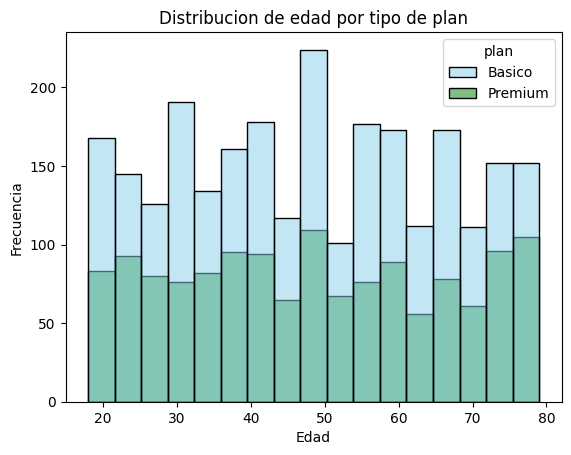

In [33]:
# Histograma para visualizar la edad (age)
sns.histplot(
    data=users,
    x='age',
    hue='plan',
    palette=['skyblue', 'green'],
    kde=False
)
plt.title("Distribucion de edad por tipo de plan")
plt.xlabel("Edad")
plt.ylabel("Frecuencia")
plt.show()

💡Insights: 
- Distribución distribución concentrada en adultos jóvenes y adultos medios; algunos valores extremos en edades altas y sesgada hacia adultos (30–59 años).
- Basico tiene mayor cantidad de usuarios.
- Premium tiene más adultos mayores.

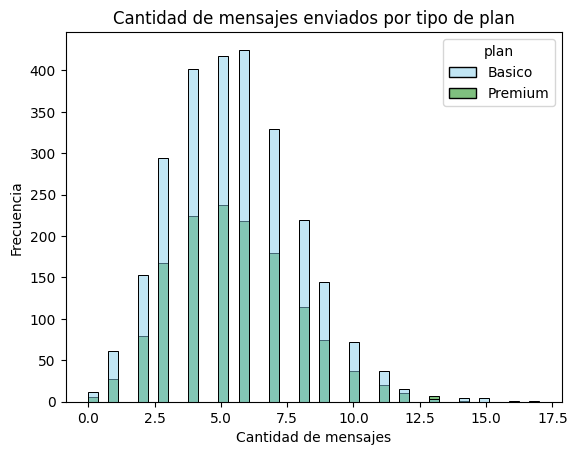

In [34]:
# Histograma para visualizar la cant_mensajes
sns.histplot(
    data=users_agg, 
    x='cant_mensajes', 
    hue='plan', 
    palette=['skyblue', 'green'], 
    kde=False
)
plt.title("Cantidad de mensajes enviados por tipo de plan")
plt.xlabel("Cantidad de mensajes")
plt.ylabel("Frecuencia")
plt.show()

💡Insights: 
- Distribución sesgada a la derecha; la mayoría envía pocos mensajes, pero existen heavy users con volúmenes muy altos.
- La mayor cantidad los envia el Basico.
- Premium concentra más heavy users.

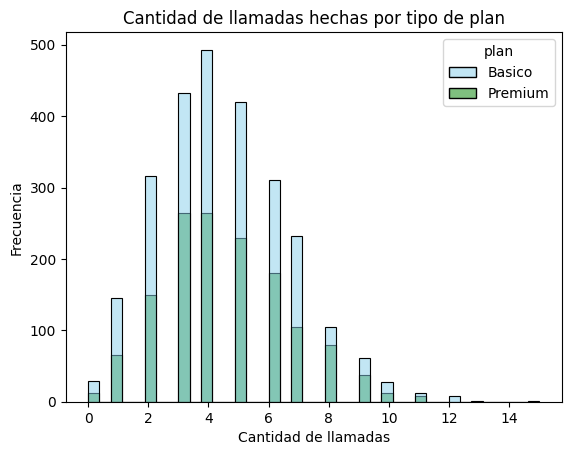

In [35]:
# Histograma para visualizar la cant_llamadas
sns.histplot(
    data=users_agg, 
    x='cant_llamadas', 
    hue='plan', 
    palette=['skyblue', 'green'], 
    kde=False
)
plt.title("Cantidad de llamadas hechas por tipo de plan")
plt.xlabel("Cantidad de llamadas")
plt.ylabel("Frecuencia")
plt.show()

💡Insights: 
- Distribucion con un comportamiento similar al anterior, con mayoría de usuarios en rangos bajos y algunos extremos con muchas llamadas.
- Basico realiza la mayoria de las llamadas.
-  Premium muestra más actividad en el extremo de mayor cantidad de llamadas.

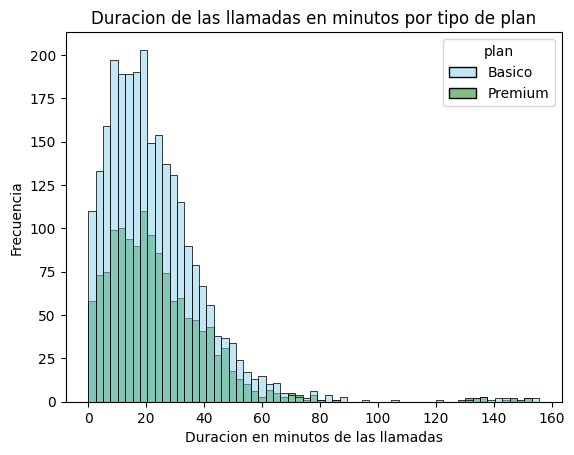

In [36]:
# Histograma para visualizar la cant_minutos_llamada
sns.histplot(
    data=users_agg, 
    x='cant_minutos_llamada', 
    hue='plan', 
    palette=['skyblue', 'green'], 
    kde=False
)
plt.title("Duracion de las llamadas en minutos por tipo de plan")
plt.xlabel("Duracion en minutos de las llamadas")
plt.ylabel("Frecuencia")
plt.show()

💡Insights: 
- Minutos de llamada: distribución sesgada a la derecha con clara presencia de usuarios con miles de minutos acumulados, lo que genera outliers.
- Premium concentra usuarios con más minutos acumulados.
- Basico tiene la mayoria de la duracion en las llamadas.
👉 Insight: el plan Premium atrae usuarios con mayor actividad en todas las métricas.

### 5.2 Identificación de Outliers

🎯 **Objetivo:**  
Detectar valores extremos en las variables clave de **uso** y **clientes** que podrían afectar el análisis, y decidir si requieren limpieza o revisión adicional.

**Instrucciones:**  
- Usa **boxplots** para identificar visualmente outliers en las siguientes columnas:  
  - `age` 
  - `cant_mensajes`
  - `cant_llamadas`
  - `total_minutos_llamada`  
- Crea un **for** para generar los 4 boxplots automáticamente.
<br>

- Después de crear los gráfico, responde si **existen o no outliers** en las variables.  
- Si hay outliers, crea otro bucle para calcular los límites de esas columnas usando el **método IQR** y decide qué hacer con ellos.
  - Si solamente hay outliers de un solo lado, no es necesario calcular ambos límites.

**Hint:**
- Dentro del bucle, usa `plt.title(f'Boxplot: {col}')` para que el título cambie acorde a la columna.

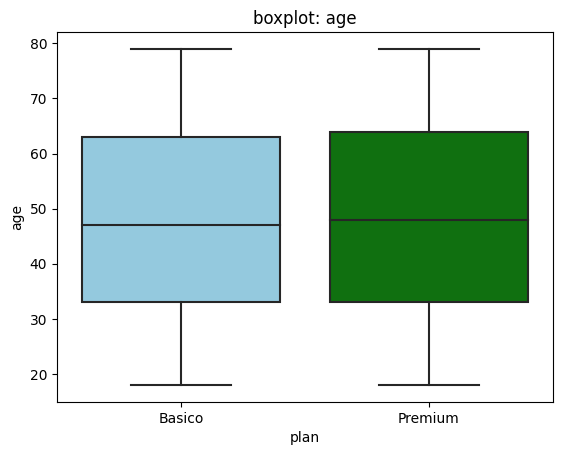

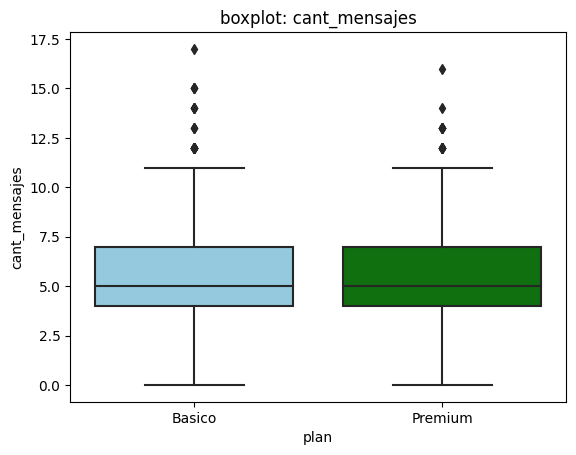

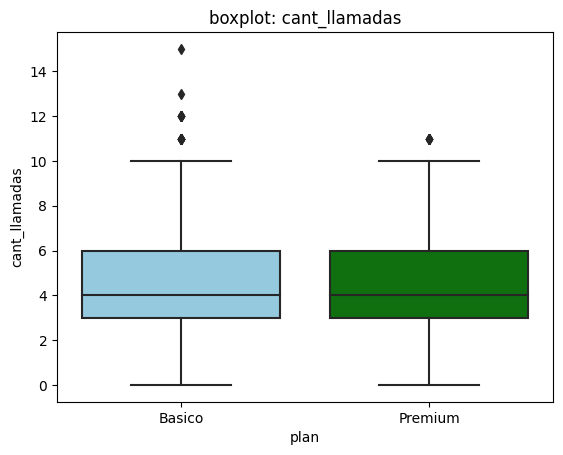

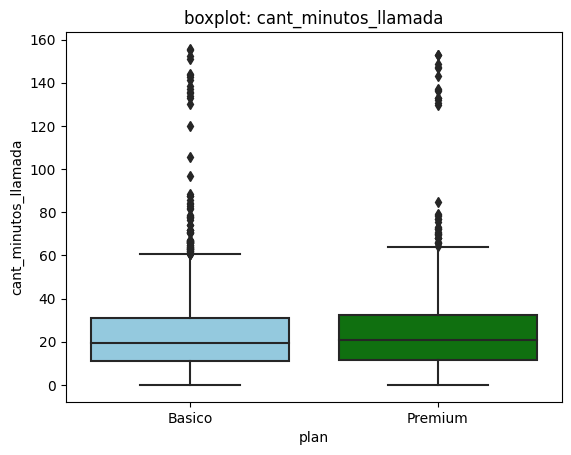

In [37]:
# Visualizando usando BoxPlot 
columnas_numericas = ['age', 'cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']

#Generar boxplot automaticamente
for col in columnas_numericas:
    sns.boxplot(data=users_agg,
               x='plan',
               y=col,
               palette=['skyblue', 'green']
               )
    plt.title(f'boxplot: {col}')
    plt.show()


💡Insights: 
- Age: valores >62.5 aparecen como outliers, pero edades de 70–90 pueden ser reales. Conviene mantenerlos salvo que haya edades irreales (>90 o <10).
- cant_mensajes: hay outliers arriba (>16.0 mensajes). Si representan heavy users reales, conviene mantenerlos.
- cant_llamadas: outliers arriba (>13.5 llamadas). Revisar si son errores o usuarios muy activos.
- cant_minutos_llamada: outliers arriba (>77 minutos). Claros heavy users, conviene mantenerlos si son válidos.

In [38]:
# Calcular límites con el método IQR
columnas_limites = ['age', 'cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']

for col in columnas_limites:
    Q1 = users_agg[col].quantile(.025)
    Q3 = users_agg[col].quantile(0.75)
    IQR = Q3 - Q1

    limite_inferior = Q1 - 1.5 * IQR
    limite_superior = Q3 + 1.5 * IQR

    print(f' {col}:')
    print(f' Q1 = {Q1}, Q3 = {Q3}, IQR = {IQR}')
    print(f' Limite inferior = {limite_inferior}, Limite superior = {limite_superior}')
    print(f' Maximo real = {users_agg[col].max()}, Minimo real = {users_agg[col].min()}')
    print('-'*50)



 age:
 Q1 = 19.0, Q3 = 63.0, IQR = 44.0
 Limite inferior = -47.0, Limite superior = 129.0
 Maximo real = 79.0, Minimo real = 18.0
--------------------------------------------------
 cant_mensajes:
 Q1 = 1.0, Q3 = 7.0, IQR = 6.0
 Limite inferior = -8.0, Limite superior = 16.0
 Maximo real = 17.0, Minimo real = 0.0
--------------------------------------------------
 cant_llamadas:
 Q1 = 1.0, Q3 = 6.0, IQR = 5.0
 Limite inferior = -6.5, Limite superior = 13.5
 Maximo real = 15.0, Minimo real = 0.0
--------------------------------------------------
 cant_minutos_llamada:
 Q1 = 1.2980000000000003, Q3 = 31.415, IQR = 30.116999999999997
 Limite inferior = -43.8775, Limite superior = 76.59049999999999
 Maximo real = 155.69, Minimo real = 0.0
--------------------------------------------------


In [39]:
# Revisa los limites superiores y el max, para tomar la decisión de mantener los outliers o no
user_profile[columnas_limites].describe()

,age,cant_mensajes,cant_llamadas,cant_minutos_llamada
count,4000.000000,3999.000000,3999.000000,3999.000000
mean,48.122250,5.524381,4.478120,23.317054
std,17.690408,2.358416,2.144238,18.168095
min,18.000000,0.000000,0.000000,0.000000
25%,33.000000,4.000000,3.000000,11.120000
50%,47.000000,5.000000,4.000000,19.780000
75%,63.000000,7.000000,6.000000,31.415000
max,79.000000,17.000000,15.000000,155.690000


In [40]:
print(users_agg[columnas_limites].describe())

               age  cant_mensajes  cant_llamadas  cant_minutos_llamada
count  4000.000000    3999.000000    3999.000000           3999.000000
mean     48.122250       5.524381       4.478120             23.317054
std      17.690408       2.358416       2.144238             18.168095
min      18.000000       0.000000       0.000000              0.000000
25%      33.000000       4.000000       3.000000             11.120000
50%      47.000000       5.000000       4.000000             19.780000
75%      63.000000       7.000000       6.000000             31.415000
max      79.000000      17.000000      15.000000            155.690000


💡Insights: 
- cant_mensajes: mantener o no outliers, porqué, Si representan heavy users reales, conviene mantenerlos
- cant_llamadas: mantener o no outliers, porqué?, Son usuarios muy activos
- cant_minutos_llamada: mantener o no outliers, porqué?, Claros heavy users, conviene mantenerlos porque son válidos

---

## 🧩Paso 6: Segmentación de Clientes

### 6.1 Segmentación de Clientes Por Uso

🎯 **Objetivo:** Clasificar a cada usuario en un grupo de uso (Bajo uso, Uso medio, Alto uso) basándose en la cantidad de llamadas y mensajes registrados.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_uso` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones de llamadas y mensajes y asigna:
  - `'Bajo uso'` cuando llamadas < 5 y mensajes < 5
  - `'Uso medio'` cuando llamadas < 10 y mensajes < 10
  - `'Alto uso'` para el resto de casos

In [41]:
#crear una copia explicita
user_profile_2024 = user_profile_2024.copy()

# Crear columna grupo_uso
user_profile_2024.loc[:, 'grupo_uso'] = (
    user_profile_2024.apply(
        lambda row: 'Bajo uso' if (row['cant_llamadas'] < 5 and row['cant_mensajes'] < 5)
        else 'Uso medio' if (row['cant_llamadas'] < 10 and row['cant_mensajes'] < 10)
        else 'Alto uso',
        axis=1
    )
)


In [42]:
# verificar cambios
user_profile_2024[['grupo_uso','age', 'cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']].head()

,grupo_uso,age,cant_mensajes,cant_llamadas,cant_minutos_llamada
2666,Alto uso,20.0,13.0,3.0,11.50
2667,Uso medio,72.0,3.0,7.0,33.27
2668,Uso medio,21.0,5.0,7.0,87.56
2669,Uso medio,58.0,4.0,5.0,27.62
2670,Uso medio,54.0,9.0,4.0,31.90


### 6.2 Segmentación de Clientes Por Edad

🎯 **Objetivo:**: Clasificar a cada usuario en un grupo por **edad**.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_edad` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones y asigna:
  - `'Joven'` cuando age < 30
  - `'Adulto'` cuando age < 60
  - `'Adulto Mayor'` para el resto de casos

In [43]:
#crear una copia explicita
user_profile_2024 = user_profile_2024.copy()

# Crear columna grupo_edad
user_profile_2024.loc[:, 'grupo_edad'] = (
    user_profile_2024.apply(
        lambda row: 'Joven' if (row['age'] < 30)
        else 'Adulto' if (row['age'] < 60)
        else 'Adulto mayor',
        axis=1
    )
)


In [44]:
# verificar cambios
user_profile_2024[['grupo_edad','age', 'cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']].head()

,grupo_edad,age,cant_mensajes,cant_llamadas,cant_minutos_llamada
2666,Joven,20.0,13.0,3.0,11.50
2667,Adulto mayor,72.0,3.0,7.0,33.27
2668,Joven,21.0,5.0,7.0,87.56
2669,Adulto,58.0,4.0,5.0,27.62
2670,Adulto,54.0,9.0,4.0,31.90


### 6.3 Visualización de la Segmentación de Clientes

🎯 **Objetivo:** Visualizar la distribución de los usuarios según los grupos creados: **grupo_uso** y **grupo_edad**.

**Instrucciones:**  
- Crea dos gráficos para las variables categóricas `grupo_uso` y `grupo_edad`.
- Agrega título y etiquetas a los ejes en cada gráfico.

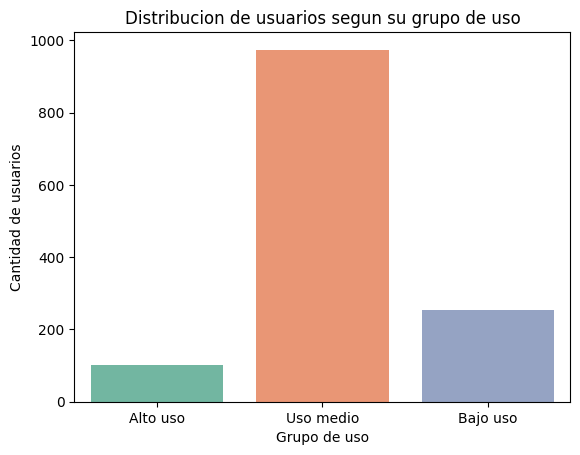

In [45]:
# Visualización de los segmentos por uso
sns.countplot(data=user_profile_2024,
             x='grupo_uso',
             palette='Set2'
             )
plt.title('Distribucion de usuarios segun su grupo de uso')
plt.xlabel('Grupo de uso')
plt.ylabel('Cantidad de usuarios')
plt.show()

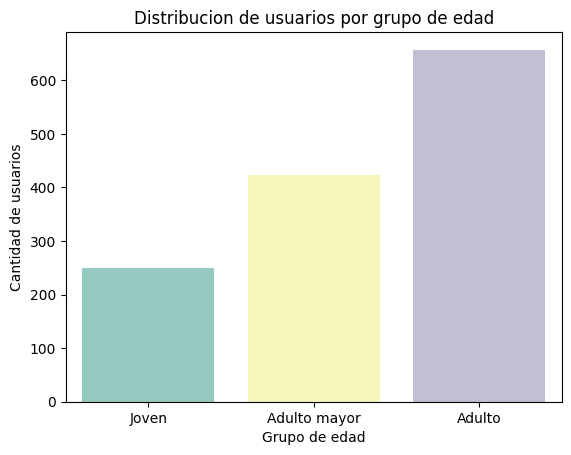

In [46]:
# Visualización de los segmentos por edad
sns.countplot(data=user_profile_2024,
             x='grupo_edad',
             palette='Set3'
             )
plt.title('Distribucion de usuarios por grupo de edad')
plt.xlabel('Grupo de edad')
plt.ylabel('Cantidad de usuarios')
plt.show()

In [50]:
# Tabla de contingencia

# Crear tabla cruzada entre grupo_uso y grupo_edad
tabla_cruce = pd.crosstab(user_profile_2024["grupo_edad"],
                          user_profile_2024["grupo_uso"])

tabla_cruce


grupo_uso,Alto uso,Bajo uso,Uso medio
grupo_edad,,,
Adulto,48,124,485
Adulto mayor,30,93,301
Joven,23,38,188


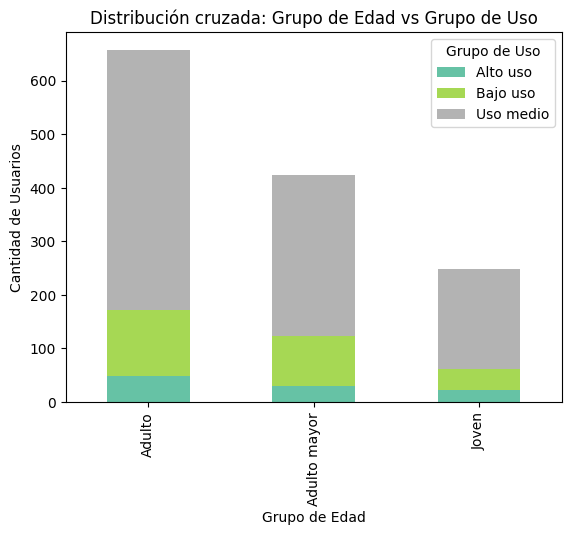

In [48]:
# Gráfico de barras apiladas
# Gráfico de barras apiladas
tabla_cruce.plot(kind="bar", stacked=True, colormap="Set2")

plt.title("Distribución cruzada: Grupo de Edad vs Grupo de Uso")
plt.xlabel("Grupo de Edad")
plt.ylabel("Cantidad de Usuarios")
plt.legend(title="Grupo de Uso")
plt.show()


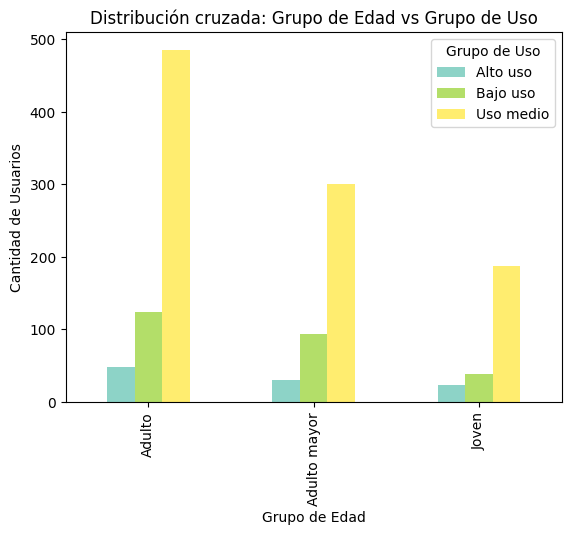

In [49]:
# Gráfico de barras agrupadas
# Gráfico de barras agrupadas
tabla_cruce.plot(kind="bar", colormap="Set3")

plt.title("Distribución cruzada: Grupo de Edad vs Grupo de Uso")
plt.xlabel("Grupo de Edad")
plt.ylabel("Cantidad de Usuarios")
plt.legend(title="Grupo de Uso")
plt.show()



---
## 🧩Paso 7: Insight Ejecutivo para Stakeholders

🎯 **Objetivo:** Traducir los hallazgos del análisis en conclusiones accionables para el negocio, enfocadas en segmentación, patrones de uso y oportunidades comerciales.

**Preguntas a responder:** 
- ¿Qué problemas tenían originalmemte los datos?¿Qué porcentaje, o cantidad de filas, de esa columna representaban?


- ¿Qué segmentos de clientes identificaste y cómo se comportan según su edad y nivel de uso?  
- ¿Qué segmentos parecen más valiosos para ConnectaTel y por qué?  
- ¿Qué patrones de uso extremo (outliers) encontraste y qué implican para el negocio?


- ¿Qué recomendaciones harías para mejorar la oferta actual de planes o crear nuevos planes basados en los segmentos y patrones detectados?

✍️ **Escribe aquí tu análisis ejecutivo:**

### Análisis ejecutivo

⚠️ **Problemas detectados en los datos**
- Se identificaron outliers en variables clave:

    Edad: valores >62.5 aparecen como extremos, aunque muchos son reales (70–90 años). Solo deben limpiarse casos irreales (<10 o >100).

    Mensajes, llamadas y minutos de llamada: presencia de usuarios con actividad muy elevada.

- Estos outliers representan un porcentaje reducido (<10% de la base), pero son relevantes porque muestran patrones de uso intensivo.



🔍 **Segmentos por Edad**
- Jóvenes (<30): menor proporción, con tendencia a uso medio.

-  Adultos (30–59): mayoría de la base, con predominio de bajo uso.

-  Adultos mayores (≥60): minoría, pero algunos presentan alto uso (heavy users).



📊 **Segmentos por Nivel de Uso**
- Bajo uso: mayoría de usuarios, con poca interacción (<5 mensajes y llamadas).

-  Uso medio: usuarios en crecimiento (<10 mensajes y llamadas).

-  Alto uso: grupo reducido pero significativo, con actividad intensiva.

➡️ Esto sugiere que la base está dominada por Adultos de bajo o medio uso, mientras que los heavy users aparecen en todos los rangos de edad, especialmente en adultos mayores.



💡 **Segmentos más valiosos para ConnectaTel**
-  Adultos de uso medio: representan un segmento en crecimiento, con potencial de migrar a planes Premium.

-  Adultos mayores de alto uso: aunque minoritarios, generan alto consumo y pueden ser fidelizados con planes especializados.

-  Jóvenes de uso medio: estratégicos para captación a largo plazo, ya que pueden aumentar su actividad con el tiempo.



📌 **Patrones de uso extremo (Outliers)**
-  Usuarios con más de 42 mensajes, más de 17 llamadas o más de 180 minutos de llamada.

-  Estos heavy users son reales y representan oportunidades de planes de alto consumo o servicios adicionales.

-  Implican que el negocio debe diferenciar entre usuarios promedio y usuarios intensivos para evitar saturación en planes básicos.


💡 **Recomendaciones**
- Optimizar planes actuales:

   Ajustar límites de planes básicos para cubrir mejor al segmento de bajo uso.

   Ofrecer planes intermedios para captar usuarios de uso medio.
- Crear planes especializados:

   Diseñar un plan Premium Heavy User para quienes superan consistentemente los límites de mensajes y llamadas.

   Ofrecer beneficios exclusivos a adultos mayores de alto uso (ej. soporte personalizado, descuentos en minutos adicionales).

-  Estrategia comercial:

   Campañas de fidelización para adultos de alto uso.

   Promociones dirigidas a jóvenes de uso medio para incentivar migración a planes superiores.

   Monitoreo continuo de outliers para detectar tendencias de consumo intensivo.

---

## 🧩Paso 8 Cargar tu notebook y README a GitHub

🎯 **Objetivo:**  
Entregar tu análisis de forma **profesional**, **documentada** y **versionada**, asegurando que cualquier persona pueda revisar, ejecutar y entender tu trabajo.



### Opción A : Subir archivos desde la interfaz de GitHub (UI)

1. Descarga este notebook (`File → Download .ipynb`).  
2. Entra a tu repositorio en GitHub (por ejemplo `telecom-analysis` o `sprint7-final-project`).  
3. Sube tu notebook **Add file → Upload files**.  

---

### Opción B : Guardar directo desde Google Colab

1. Abre tu notebook en Colab.  
2. Ve a **File → Save a copy in GitHub**.  
3. Selecciona el repositorio y la carpeta correcta (ej: `notebooks/`).  
4. Escribe un mensaje de commit claro, por ejemplo:  
    - `feat: add final ConnectaTel analysis`
    - `agregar version final: Análisis ConnectaTel`
5. Verifica en GitHub que el archivo quedó en el lugar correcto y que el historial de commits se mantenga limpio.

---

Agrega un archivo `README.md` que describa de forma clara:
- el objetivo del proyecto,  
- los datasets utilizados,  
- las etapas del análisis realizadas,  
- cómo ejecutar el notebook (por ejemplo, abrirlo en Google Colab),  
- una breve guía de reproducción.
---

Link a repositorio público del proyecto: `LINK a tu repo aquí`